# TRIBE v2 Demo: Predicting Brain Responses to Naturalistic Stimuli

[TRIBE v2](https://github.com/facebookresearch/tribev2) is a deep multimodal brain encoding model that predicts **fMRI brain responses** to naturalistic stimuli — video, audio, and text.

It combines state-of-the-art feature extractors — **LLaMA 3.2** (text), **V-JEPA2** (video), and **Wav2Vec-BERT** (audio) — into a unified Transformer that maps multimodal representations onto the cortical surface (**fsaverage5**, ~20k vertices).

In this notebook, we will:
1. Load a pretrained TRIBE v2 model from HuggingFace
2. Predict brain responses to a **video** clip
3. Predict brain responses to **audio** generated from text
4. Visualize the predicted activity on a 3D brain surface

> **Note (Mac M4 / MPS):** This notebook has been adapted for local execution on Apple Silicon (M4) with MPS acceleration. The `tribev2` package includes monkey-patching for MPS device support. Ensure `PYTORCH_ENABLE_MPS_FALLBACK=1` is set in your environment (this is done automatically by the `tribev2` package).


## Setup

### For local Mac M4 users:
1. Ensure you have the `tribev2` package installed in your virtual environment: `pip install -e ".[plotting]"`
2. The MPS compatibility patches are applied automatically when importing `tribev2`
3. `PYTORCH_ENABLE_MPS_FALLBACK=1` is set automatically

### For Colab users:
1. Activate the GPU (Menu > Runtime > Change runtime)
2. Run the install command below
3. Restart your environment for the new packages to be taken into account


In [1]:
# For Colab users only — skip this cell if running locally
# !uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

# For local Mac M4 users, ensure tribev2 is installed in your venv:
# pip install -e ".[plotting]"
print("Setup complete. If running locally, ensure tribev2 is installed in your venv.")


Setup complete. If running locally, ensure tribev2 is installed in your venv.


## Loading the model

We load TRIBE v2 model from [HuggingFace Hub](https://huggingface.co/facebook/tribev2). On the first run, this downloads the model checkpoint and config (~1 GB). Subsequent runs use the cached version.

We also initialize a `PlotBrain` object for 3D brain surface visualization using the **fsaverage5** mesh.

> **Mac M4 Note:** The model will automatically load on the MPS device thanks to the monkey-patching in `tribev2/_mps_compat.py`. Feature extractors will resolve `device='auto'` to `mps` when CUDA is unavailable.


In [2]:
from tribev2.demo_utils import TribeModel, download_file
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    config_update={
        # Use ungated mirror (no HF auth needed)
        "data.text_feature.model_name": "alpindale/Llama-3.2-3B",
        # Llama GQA attention is incompatible with MPS matmul;
        # CPU is fine on Apple Silicon (unified memory).
        "data.text_feature.device": "cpu",
    },
)

plotter = PlotBrain(mesh="fsaverage5")


/Volumes/dev/ai_work/meta/tribe_v2/code/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Volumes/dev/ai_work/meta/tribe_v2/code/.venv/lib/python3.11/site-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-04-13 00:01:11 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.
/Volumes/dev/ai_work/meta/tribe_v2/code/.venv/lib/python3.11/site-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been 

## Predict brain responses to a video

Given a video file, TRIBE v2 automatically:
1. **Extracts audio** from the video track
2. **Transcribes speech** into word-level events with timestamps using [**WhisperX**](https://github.com/m-bain/whisperx)
3. **Extracts visual features** (DINOv2 + V-JEPA2) and **audio features** (Wav2Vec-BERT) and **text features** (LLaMA 3.2)
4. **Predicts fMRI activity** at each time step (1 TR = 1 second) across the cortical surface

Below, we download a sample video ([Sintel trailer](https://durian.blender.org/)), build an events dataframe, and run the model.

In [ ]:
df = model.get_events_dataframe(text_path="sample_text.txt")
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

INFO - Downloaded https://download.blender.org/durian/trailer/sintel_trailer-480p.mp4 -> cache/sample_video.mp4


,type,start,duration,filepath,text,context
0,Audio,0.000000,1.416000,cache/tribev2.demo_utils.TextToEvents.get_even...,NaN,
1,Sentence,0.212999,0.912002,NaN,Hello world!,
2,Text,0.213000,0.912000,NaN,Hello world!,
3,Word,0.213000,0.426000,NaN,Hello,Hello
4,Word,0.720000,0.405000,NaN,world!,Hello world!


### Run the model

We feed the events dataframe to `model.predict()`, which extracts features for each modality, runs them through the Transformer, and returns predicted brain activity.

> **Note:** On Mac M4, feature extraction (especially WhisperX for transcription) runs on CPU with `int8` quantization for best compatibility. The TRIBE model itself runs on MPS.

The output `preds` has shape `(n_timesteps, n_vertices)` — one prediction per second of stimulus, with ~20k cortical vertices. The `segments` list contains the corresponding time segments with their associated events.


In [4]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")


[00:01:25 WARNING] Removing extractor video as there are no corresponding events
[00:01:25 INFO] Preparing extractor: text
100%|██████████| 2/2 [00:22<00:00, 11.12s/it]
[00:01:48 INFO] Preparing extractor: audio
Loading weights: 100%|██████████| 773/773 [00:00<00:00, 5913.18it/s]
[00:01:56 INFO] Preparing extractor: subject_id
2026-04-13 00:01:56 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[00:01:57 INFO] Building dataloader for split all
100%|██████████| 1/1 [00:54<00:00, 54.94s/it]
INFO - Predicted 2 / 100 segments (2.0% kept)


Predictions shape: (2, 20484)  (n_timesteps, n_vertices)


### Visualize predictions on the brain surface

We plot the predicted fMRI activity for the first 15 time steps on the fsaverage5 cortical mesh. Each panel shows one second of predicted activity, with the corresponding stimulus frame displayed below. Predictions are offset by 5 seconds in the past, in order to compensate for the hemodynamic lag.

We see that as the image appears on the screen, the visual cortex lights up (t=4s), followed by the language network when the character starts to speak (t=12s).

Plotting...: 100%|██████████| 2/2 [00:00<00:00,  3.04it/s]


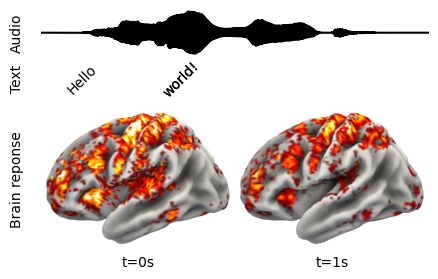

: 

In [ ]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)

## Predict brain responses to text (via text-to-speech)

TRIBE v2 can also predict brain responses to **text** input. Since the model was trained on naturalistic audio/video stimuli, text is first converted to speech using Google Text-to-Speech (gTTS), then transcribed back to obtain precise word-level timings.

Below, we use a passage from Shakespeare's *Hamlet* as input.

In [ ]:
text = """
To be or not to be, that is the question.
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep,
No more; and by a sleep to say we end
The heartache and the thousand natural shocks
"""

text_path = CACHE_FOLDER / "shakespeare.txt"
text_path.write_text(text)

df = model.get_events_dataframe(text_path=text_path)
display(df.head(8)[["type", "start", "duration", "filepath", "text", "context"]])

### Run the model

Same as before — we pass the events dataframe to `model.predict()` to get brain activity predictions for each time step.

In [ ]:
preds, segments = model.predict(events=df)
print(f"Predictions shape: {preds.shape}  (n_timesteps, n_vertices)")

### Visualize predictions on the brain surface

Again, we visualize the first 15 seconds of predicted activity. For audio-only stimuli, the stimulus display shows the spoken words at each time step.

In [ ]:
n_timesteps = 15
fig = plotter.plot_timesteps(preds[:n_timesteps], segments=segments[:n_timesteps], cmap="fire", norm_percentile=99, vmin=.6, alpha_cmap=(0, .2), show_stimuli=True)